In [17]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# --- Device ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

# --- Load AR dataset ---
data = np.load('/content/ar_database_stacked_128x128.npz')
stack = data['stack']
X = stack / 255.0
X = X.reshape(X.shape[0], -1)  # flatten
X = torch.tensor(X, dtype=torch.float32, device=device)
n_samples, n_features = X.shape
print("Data loaded. Shape:", X.shape)

# --- Parameters ---
r = 50        # number of principal components
h = 100       # number of activated error terms
sigma = 1.0   # adaptive loss parameter
gamma = 1.0   # regularization for weights
max_iter = 10

# --- Step 0: Initialization ---
p = torch.ones(n_samples, device=device) / n_samples
b = torch.mean(X, dim=0)
W = torch.randn(n_features, r, device=device)
U_diag = torch.ones(n_samples, device=device)

print("Initialization complete:")
print(f"p shape: {p.shape}, sum(p): {p.sum().item()}")
print(f"b shape: {b.shape}")
print(f"W shape: {W.shape}")
print(f"U_diag shape: {U_diag.shape}")

# --- Main Iterative Loop ---
for iteration in range(max_iter):
    print(f"\n=== Iteration {iteration+1} ===")

    # --- Step 1: Update W ---
    print("Step 1: Updating W...")
    try:
        # weighted data for SVD
        X_weighted = X.T * torch.sqrt(U_diag)
        _, _, Vt = torch.linalg.svd(X_weighted.T, full_matrices=False)
        W = Vt.T[:, :r]
        print("W updated. Shape:", W.shape)
    except Exception as e:
        print("Error updating W:", e)

    # --- Step 2: Update b ---
    print("Step 2: Updating b...")
    b = (X.T @ U_diag) / U_diag.sum()
    print("b updated. Shape:", b.shape)
    print("Sample b values:", b[:5].cpu().numpy())

    # --- Step 3: Update U_diag (adaptive normalization) ---
    print("Step 3: Updating U_diag...")
    avg_local_dist = torch.sum((X - X.mean(dim=0))**2, dim=1) + sigma
    U_diag = n_samples * p * (1 + sigma) / avg_local_dist
    print("U_diag updated. Sample values:", U_diag[:10].cpu().numpy())

    # --- Step 4: Update weights p (top-h logic) ---
    print("Step 4: Updating weights p...")
    recon_error = torch.sum((X - (X @ W @ W.T + b))**2, dim=1)

    # Top-h threshold
    sorted_errors, _ = torch.sort(recon_error)
    eta = sorted_errors[h-1]  # h-th smallest reconstruction error

    # Compute p_i
    p = torch.clamp((eta - recon_error) / (2 * gamma), min=0)

    # Normalize
    if p.sum() > 0:
        p = p / p.sum()

    print("p updated. Sum(p):", p.sum().item())
    print("Number of non-zero weights:", (p > 0).sum().item())
    print("Sample weights (first 10):", p[:10].cpu().numpy())

print("\nAlgorithm 1 finished successfully.")
X_recon_AR = X @ W @ W.T + b  # store reconstruction for AR

Using device: cuda
Data loaded. Shape: torch.Size([3315, 16384])
Initialization complete:
p shape: torch.Size([3315]), sum(p): 1.0
b shape: torch.Size([16384])
W shape: torch.Size([16384, 50])
U_diag shape: torch.Size([3315])

=== Iteration 1 ===
Step 1: Updating W...
W updated. Shape: torch.Size([16384, 50])
Step 2: Updating b...
b updated. Shape: torch.Size([16384])
Sample b values: [0.15628219 0.22310852 0.22398981 0.22445    0.22484037]
Step 3: Updating U_diag...
U_diag updated. Sample values: [0.02657653 0.0195185  0.01568739 0.00979273 0.00740067 0.01704098
 0.02590631 0.03223599 0.00903101 0.01364727]
Step 4: Updating weights p...
p updated. Sum(p): 1.0
Number of non-zero weights: 99
Sample weights (first 10): [0.         0.         0.         0.         0.         0.
 0.         0.02466478 0.         0.        ]

=== Iteration 2 ===
Step 1: Updating W...
W updated. Shape: torch.Size([16384, 50])
Step 2: Updating b...
b updated. Shape: torch.Size([16384])
Sample b values: [0.156


--- Reconstruction Evaluation ---
Mean reconstruction error over all samples: 0.11340732872486115
Min reconstruction error: 0.11028258502483368
Max reconstruction error: 0.1259482204914093


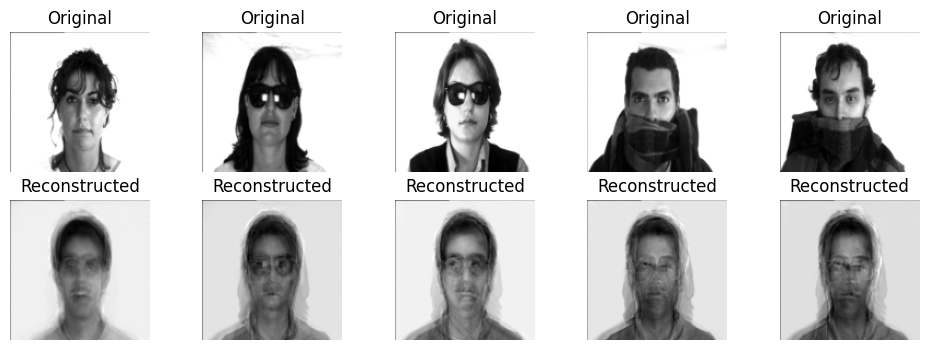


Weight statistics after final iteration:
Max weight: 0.013207046315073967
Min weight: 0.0
Number of non-zero weights: 99
Sample of weights (first 20): [0.         0.         0.         0.         0.         0.
 0.         0.01245375 0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.        ]


In [18]:
# --- Reconstruction and Evaluation ---
print("\n--- Reconstruction Evaluation ---")

# Reconstruct all samples
X_recon = X @ W @ W.T + b

# Compute per-sample reconstruction errors (mean squared error)
reconstruction_errors = torch.mean((X - X_recon)**2, dim=1)
print("Mean reconstruction error over all samples:", reconstruction_errors.mean().item())
print("Min reconstruction error:", reconstruction_errors.min().item())
print("Max reconstruction error:", reconstruction_errors.max().item())

# --- Visualize original vs reconstructed images ---
num_visualize = 5  # number of images to visualize
img_h, img_w = stack.shape[1], stack.shape[2]

plt.figure(figsize=(12, 4))
for i in range(num_visualize):
    # Original
    plt.subplot(2, num_visualize, i+1)
    plt.imshow(X[i].cpu().reshape(img_h, img_w), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstructed
    plt.subplot(2, num_visualize, i+1+num_visualize)
    plt.imshow(X_recon[i].cpu().reshape(img_h, img_w), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.show()

# --- Print weight statistics ---
print("\nWeight statistics after final iteration:")
print("Max weight:", p.max().item())
print("Min weight:", p.min().item())
print("Number of non-zero weights:", (p > 0).sum().item())
print("Sample of weights (first 20):", p[:20].cpu().numpy())

In [19]:
import zipfile
import os

zip_path = '/content/jaffe.zip'
extract_dir = '/content/jaffe'


with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)
print(f"Extracted JAFFE dataset to {extract_dir}")


print("\nContents of the extracted folder:")
for root, dirs, files in os.walk(extract_dir):
    print(f"\nFolder: {root}")
    print(f"Subfolders: {dirs}")
    print(f"Files (first 10 shown): {files[:10]}")

Extracted JAFFE dataset to /content/jaffe

Contents of the extracted folder:

Folder: /content/jaffe
Subfolders: ['jaffe']
Files (first 10 shown): ['README_FIRST.txt']

Folder: /content/jaffe/jaffe
Subfolders: []
Files (first 10 shown): ['UY.DI1.149.tiff', 'KR.HA1.74.tiff', 'MK.DI3.130.tiff', 'MK.AN3.127.tiff', 'KR.DI3.88.tiff', 'KA.SU3.38.tiff', 'KM.HA1.4.tiff', 'KA.SU2.37.tiff', 'MK.NE3.115.tiff', 'KA.SU1.36.tiff']


In [20]:
import os
from PIL import Image
import numpy as np

# Path to JAFFE images
jaffe_folder = '/content/jaffe/jaffe'


image_files = [f for f in os.listdir(jaffe_folder) if f.lower().endswith('.tiff')]
image_files.sort()  # optional: sort for consistent order

print(f"Number of images found: {len(image_files)}")
print("First 10 images:", image_files[:10])


images_list = []
for idx, img_file in enumerate(image_files):
    img_path = os.path.join(jaffe_folder, img_file)
    img = Image.open(img_path).convert('L')  # convert to grayscale
    img_array = np.array(img, dtype=np.float32) / 255.0  # normalize to 0-1
    images_list.append(img_array.flatten())  # flatten for PCA/N-RPCA
    if idx < 5:
        print(f"Loaded {img_file}, shape: {img_array.shape}")


X_jaffe = np.stack(images_list)
print("Final JAFFE array shape (n_samples, n_features):", X_jaffe.shape)

Number of images found: 213
First 10 images: ['KA.AN1.39.tiff', 'KA.AN2.40.tiff', 'KA.AN3.41.tiff', 'KA.DI1.42.tiff', 'KA.DI2.43.tiff', 'KA.DI3.44.tiff', 'KA.FE1.45.tiff', 'KA.FE2.46.tiff', 'KA.FE3.47.tiff', 'KA.FE4.48.tiff']
Loaded KA.AN1.39.tiff, shape: (256, 256)
Loaded KA.AN2.40.tiff, shape: (256, 256)
Loaded KA.AN3.41.tiff, shape: (256, 256)
Loaded KA.DI1.42.tiff, shape: (256, 256)
Loaded KA.DI2.43.tiff, shape: (256, 256)
Final JAFFE array shape (n_samples, n_features): (213, 65536)


Using device: cuda
JAFFE tensor shape: torch.Size([213, 65536])
Initialization complete.
p sum: 1.0, b shape: torch.Size([65536]), W shape: torch.Size([65536, 50])

=== Iteration 1 ===
Updating W...
W updated. Shape: torch.Size([65536, 50])
Updating b...
b updated. Sample values (first 5): [0.4704594  0.47027528 0.47833925 0.47951758 0.48150596]
Updating U_diag...
U_diag sample values (first 10): [0.00205048 0.00154498 0.00179564 0.00201513 0.00198326 0.00168355
 0.00191241 0.00177871 0.00171631 0.00154123]
Updating weights p...
p sum: 1.0 Non-zero weights: 49
Sample weights (first 10): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

=== Iteration 2 ===
Updating W...
W updated. Shape: torch.Size([65536, 50])
Updating b...
b updated. Sample values (first 5): [0.44978014 0.45011947 0.45864087 0.45952752 0.46180636]
Updating U_diag...
U_diag sample values (first 10): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Updating weights p...
p sum: 1.0 Non-zero weights: 49
Sample weights (first 10): [0.         0.         0.

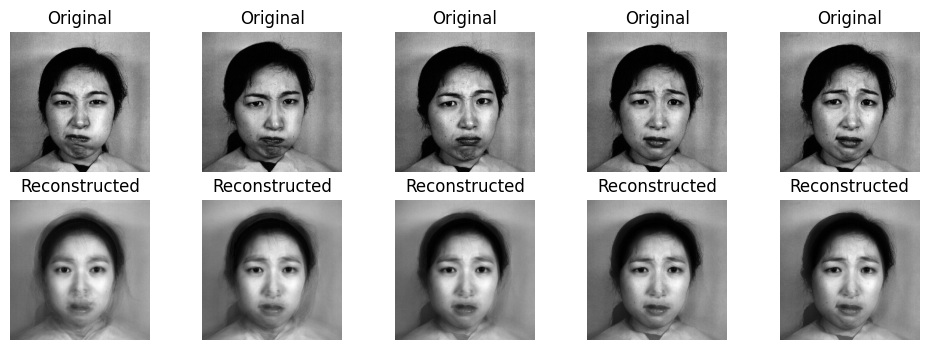


Final weight statistics:
Max weight: 0.020418114960193634
Min weight: 0.0
Number of non-zero weights: 49
Sample of first 20 weights: [0.         0.         0.         0.0204072  0.02040626 0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.02041484 0.0204164  0.         0.
 0.         0.        ]


In [21]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# --- Device ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

# Convert JAFFE array to torch tensor on GPU
X_jaffe_tensor = torch.tensor(X_jaffe, dtype=torch.float32, device=device)
n_samples, n_features = X_jaffe_tensor.shape
img_h, img_w = 256, 256
print("JAFFE tensor shape:", X_jaffe_tensor.shape)

# --- Parameters ---
r = 50        # number of principal components
h = 50        # number of activated error terms (top-h)
sigma = 1.0
gamma = 1.0
max_iter = 10

# --- Step 0: Initialization ---
p = torch.ones(n_samples, device=device) / n_samples
b = torch.mean(X_jaffe_tensor, dim=0)
W = torch.randn(n_features, r, device=device)
U_diag = torch.ones(n_samples, device=device)

print("Initialization complete.")
print(f"p sum: {p.sum().item()}, b shape: {b.shape}, W shape: {W.shape}")

# --- Main Iterative Loop ---
for iteration in range(max_iter):
    print(f"\n=== Iteration {iteration+1} ===")

    # Step 1: Update W using weighted SVD
    print("Updating W...")
    try:
        X_weighted = X_jaffe_tensor.T * torch.sqrt(U_diag)
        _, _, Vt = torch.linalg.svd(X_weighted.T, full_matrices=False)
        W = Vt.T[:, :r]
        print("W updated. Shape:", W.shape)
    except Exception as e:
        print("Error updating W:", e)

    # Step 2: Update b (weighted mean)
    print("Updating b...")
    b = (X_jaffe_tensor.T @ U_diag) / U_diag.sum()
    print("b updated. Sample values (first 5):", b[:5].cpu().numpy())

    # Step 3: Update U_diag (adaptive normalization)
    print("Updating U_diag...")
    avg_local_dist = torch.sum((X_jaffe_tensor - X_jaffe_tensor.mean(dim=0))**2, dim=1) + sigma
    U_diag = n_samples * p * (1 + sigma) / avg_local_dist
    print("U_diag sample values (first 10):", U_diag[:10].cpu().numpy())

    # Step 4: Update weights p (top-h logic)
    print("Updating weights p...")
    recon_error = torch.sum((X_jaffe_tensor - (X_jaffe_tensor @ W @ W.T + b))**2, dim=1)
    sorted_errors, _ = torch.sort(recon_error)
    eta = sorted_errors[h-1]  # top-h smallest
    p = torch.clamp((eta - recon_error) / (2 * gamma), min=0)
    if p.sum() > 0:
        p = p / p.sum()
    print("p sum:", p.sum().item(), "Non-zero weights:", (p > 0).sum().item())
    print("Sample weights (first 10):", p[:10].cpu().numpy())

print("\nN-RPCA on JAFFE finished successfully.")

# --- Reconstruction ---
X_recon = X_jaffe_tensor @ W @ W.T + b
reconstruction_errors = torch.mean((X_jaffe_tensor - X_recon)**2, dim=1)
print("\nReconstruction error over samples:")
print("Mean:", reconstruction_errors.mean().item())
print("Min:", reconstruction_errors.min().item())
print("Max:", reconstruction_errors.max().item())

# --- Visualization: original vs reconstructed ---
num_visualize = 5
plt.figure(figsize=(12, 4))
for i in range(num_visualize):
    # Original
    plt.subplot(2, num_visualize, i+1)
    plt.imshow(X_jaffe_tensor[i].cpu().reshape(img_h, img_w), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstructed
    plt.subplot(2, num_visualize, i+1+num_visualize)
    plt.imshow(X_recon[i].cpu().reshape(img_h, img_w), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.show()

# --- Print final weight statistics ---
print("\nFinal weight statistics:")
print("Max weight:", p.max().item())
print("Min weight:", p.min().item())
print("Number of non-zero weights:", (p > 0).sum().item())
print("Sample of first 20 weights:", p[:20].cpu().numpy())

X_recon_JAFFE = X_jaffe_tensor @ W @ W.T + b  # store reconstruction for JAFFE

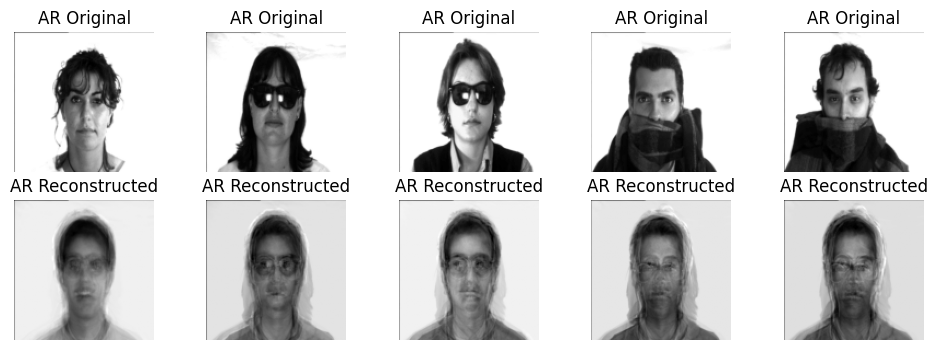

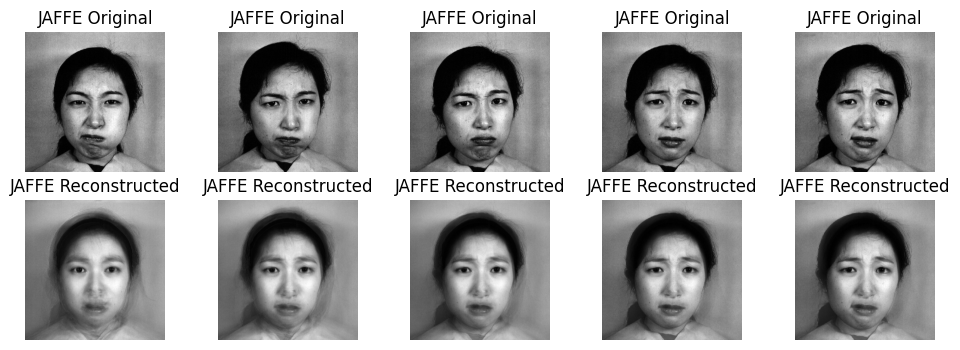

In [22]:
# Visualize AR dataset (128x128)
num_visualize = 5
plt.figure(figsize=(12, 4))
for i in range(num_visualize):
    plt.subplot(2, num_visualize, i+1)
    plt.imshow(X[i].cpu().reshape(128,128), cmap='gray')
    plt.title("AR Original")
    plt.axis('off')

    plt.subplot(2, num_visualize, i+1+num_visualize)
    plt.imshow(X_recon_AR[i].cpu().reshape(128,128), cmap='gray')
    plt.title("AR Reconstructed")
    plt.axis('off')
plt.show()

# Visualize JAFFE dataset (256x256)
plt.figure(figsize=(12, 4))
for i in range(num_visualize):
    plt.subplot(2, num_visualize, i+1)
    plt.imshow(X_jaffe_tensor[i].cpu().reshape(256,256), cmap='gray')
    plt.title("JAFFE Original")
    plt.axis('off')

    plt.subplot(2, num_visualize, i+1+num_visualize)
    plt.imshow(X_recon_JAFFE[i].cpu().reshape(256,256), cmap='gray')
    plt.title("JAFFE Reconstructed")
    plt.axis('off')
plt.show()